In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [3]:
words = open('names.txt', 'r').read().splitlines()
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
block_size = 3
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [6]:
X.shape

torch.Size([32, 3])

In [7]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [8]:
C = torch.randn(27,2)

In [9]:
for idx in range(len(C)):
    print(C[idx])
    print(itos[idx])

tensor([-0.2155,  0.4941])
.
tensor([-0.9471,  1.4272])
a
tensor([-0.9415, -0.6919])
b
tensor([-2.2402,  1.1082])
c
tensor([0.0432, 0.3803])
d
tensor([1.7761, 0.8739])
e
tensor([-1.2203, -0.8567])
f
tensor([-0.6691, -2.0796])
g
tensor([-1.4822,  0.7025])
h
tensor([2.2860, 0.6180])
i
tensor([-1.5095, -0.6092])
j
tensor([1.0896, 0.6652])
k
tensor([-0.3673,  0.3916])
l
tensor([-1.5374, -0.2554])
m
tensor([ 0.4566, -0.0038])
n
tensor([ 0.7533, -0.2783])
o
tensor([1.2888, 1.7189])
p
tensor([0.4703, 2.6194])
q
tensor([-0.6839, -1.9350])
r
tensor([ 1.3098, -0.1786])
s
tensor([0.6036, 1.3814])
t
tensor([-0.9457, -1.1345])
u
tensor([-1.9401, -0.3300])
v
tensor([-0.4901,  0.6137])
w
tensor([1.9619, 0.8423])
x
tensor([ 0.5600, -0.7893])
y
tensor([0.3066, 0.1914])
z


In [10]:
C[X]

tensor([[[-0.2155,  0.4941],
         [-0.2155,  0.4941],
         [-0.2155,  0.4941]],

        [[-0.2155,  0.4941],
         [-0.2155,  0.4941],
         [ 1.7761,  0.8739]],

        [[-0.2155,  0.4941],
         [ 1.7761,  0.8739],
         [-1.5374, -0.2554]],

        [[ 1.7761,  0.8739],
         [-1.5374, -0.2554],
         [-1.5374, -0.2554]],

        [[-1.5374, -0.2554],
         [-1.5374, -0.2554],
         [-0.9471,  1.4272]],

        [[-0.2155,  0.4941],
         [-0.2155,  0.4941],
         [-0.2155,  0.4941]],

        [[-0.2155,  0.4941],
         [-0.2155,  0.4941],
         [ 0.7533, -0.2783]],

        [[-0.2155,  0.4941],
         [ 0.7533, -0.2783],
         [-0.3673,  0.3916]],

        [[ 0.7533, -0.2783],
         [-0.3673,  0.3916],
         [ 2.2860,  0.6180]],

        [[-0.3673,  0.3916],
         [ 2.2860,  0.6180],
         [-1.9401, -0.3300]],

        [[ 2.2860,  0.6180],
         [-1.9401, -0.3300],
         [ 2.2860,  0.6180]],

        [[-1.9401, -0

In [11]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [12]:
W1 = torch.rand(6,100)
b1 = torch.rand(100)

In [13]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([32, 6])

In [14]:
torch.cat(torch.unbind(emb, 1),1).shape

torch.Size([32, 6])

In [15]:
h = (emb.view(-1,6)) @ W1 + b1
#h = (emb.view(32,6)) @ W1 + b1
#h = (emb.view(emb.shape[0],6)) @ W1 + b1

W1.shape == 32,100

B1.shape == 100

32,100

1 ,100

broadcastable because each column has either equal values, 1, or DNE value

(emb.view(32,6)) @ W1 + b1 == (emb.view(-1,6)) @ W1 + b1 == (emb.view(emb.shape[0],6)) @ W1 + b1


In [16]:
h = torch.tanh(h)

In [17]:
W2 = torch.rand(100,27)
B2 = torch.rand(27)

In [18]:
logits = h @ W2 + B2

In [19]:
logits.shape

torch.Size([32, 27])

In [20]:
counts = logits.exp()

In [21]:
prob = counts/counts.sum(1,keepdims=True)

In [22]:
prob.shape

torch.Size([32, 27])

In [23]:
prob

tensor([[1.6667e-02, 3.8868e-03, 7.2648e-03, 4.7810e-02, 9.3346e-02, 3.8710e-02,
         2.0868e-02, 6.1126e-02, 2.1264e-02, 1.3679e-02, 5.9275e-05, 6.1760e-03,
         2.9748e-01, 1.0999e-02, 8.0600e-03, 1.2349e-01, 1.8079e-03, 6.2959e-04,
         5.2275e-02, 2.5858e-03, 8.0622e-02, 9.7350e-04, 7.8953e-04, 4.9056e-03,
         5.5526e-02, 3.9114e-03, 2.5084e-02],
        [1.1111e-02, 2.6626e-03, 4.3922e-03, 1.2499e-02, 8.7326e-02, 6.5905e-02,
         8.3983e-03, 2.0885e-02, 1.4698e-02, 1.4678e-02, 7.4131e-06, 8.2379e-03,
         1.2630e-01, 1.0693e-03, 2.3500e-03, 3.5172e-01, 1.2509e-04, 1.0089e-04,
         6.0111e-02, 1.5060e-03, 1.1959e-01, 3.4069e-04, 6.0502e-05, 1.0752e-03,
         4.2991e-02, 2.5033e-03, 3.9355e-02],
        [3.2920e-03, 6.1038e-04, 7.2772e-03, 3.1311e-02, 2.7849e-02, 8.6038e-03,
         1.2664e-02, 6.7151e-03, 1.2483e-02, 7.3657e-03, 1.0460e-05, 5.9767e-03,
         4.8564e-01, 5.3228e-03, 6.5234e-03, 2.9524e-01, 1.8588e-04, 1.0593e-03,
         5.8761e-

In [24]:
prob[0].sum()

tensor(1.0000)

In [25]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(5.0850)

In [26]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

# Cleaned Version 1

In [27]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [28]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [34]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])


TypeError: cannot unpack non-iterable NoneType object

In [35]:
words[1]

'diondre'

In [29]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,30), generator=g, requires_grad=True)
W1 = torch.randn((30,300), generator=g, requires_grad=True)
b1 = torch.randn(300, generator=g, requires_grad=True)
W2 = torch.randn((300,27), generator=g, requires_grad=True)
b2 = torch.randn(27,generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]


In [30]:
sum(p.nelement() for p in parameters)

18237

In [31]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []

for i in range(1000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0],(32,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    lossi.append(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

RuntimeError: mat1 and mat2 shapes cannot be multiplied (480x6 and 30x300)

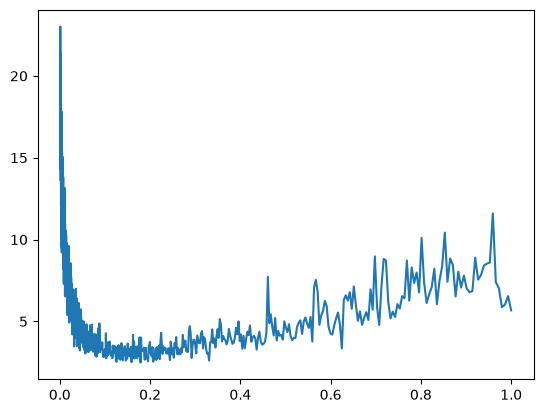

In [ ]:
plt.plot(lrs,lossi)